In [60]:
# from google.colab import drive


# drive.mount('/content/drive')


# Reading the Dataset

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.tseries.holiday import USFederalHolidayCalendar


path = '2023_Yellow_Taxi_Trip_Data.csv'

df = pd.read_csv(path)

/var/folders/6_/4pssx0rj0ln4w7ysqm50xw400000gn/T/ipykernel_3484/2590903611.py:9: DtypeWarning: Columns (4,6,10,11,13,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


# Dataset Head

In [62]:
df.head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,01/01/2023 12:32:10 AM,01/01/2023 12:40:36 AM,1.0,0.97,1.0,N,161,141,2,9.3,1.0,0.5,0.0,0.0,1.0,14.3,2.5,0.00
1,2,01/01/2023 12:55:08 AM,01/01/2023 01:01:27 AM,1.0,1.1,1.0,N,43,237,1,7.9,1.0,0.5,4.0,0.0,1.0,16.9,2.5,0.00
2,2,01/01/2023 12:25:04 AM,01/01/2023 12:37:49 AM,1.0,2.51,1.0,N,48,238,1,14.9,1.0,0.5,15.0,0.0,1.0,34.9,2.5,0.00
3,1,01/01/2023 12:03:48 AM,01/01/2023 12:13:25 AM,0.0,1.9,1.0,N,138,7,1,12.1,7.25,0.5,0.0,0.0,1.0,20.85,0.0,1.25
4,2,01/01/2023 12:10:29 AM,01/01/2023 12:21:19 AM,1.0,1.43,1.0,N,107,79,1,11.4,1.0,0.5,3.28,0.0,1.0,19.68,2.5,0.00
5,2,01/01/2023 12:50:34 AM,01/01/2023 01:02:52 AM,1.0,1.84,1.0,N,161,137,1,12.8,1.0,0.5,10.0,0.0,1.0,27.8,2.5,0.00
6,2,01/01/2023 12:09:22 AM,01/01/2023 12:19:49 AM,1.0,1.66,1.0,N,239,143,1,12.1,1.0,0.5,3.42,0.0,1.0,20.52,2.5,0.00
7,2,01/01/2023 12:27:12 AM,01/01/2023 12:49:56 AM,1.0,11.7,1.0,N,142,200,1,45.7,1.0,0.5,10.74,3.0,1.0,64.44,2.5,0.00
8,2,01/01/2023 12:21:44 AM,01/01/2023 12:36:40 AM,1.0,2.95,1.0,N,164,236,1,17.7,1.0,0.5,5.68,0.0,1.0,28.38,2.5,0.00
9,2,01/01/2023 12:39:42 AM,01/01/2023 12:50:36 AM,1.0,3.01,1.0,N,141,107,2,14.9,1.0,0.5,0.0,0.0,1.0,19.9,2.5,0.00


# Dataset Features

In [63]:
print(f"LISTED FEATURES:\n{df.iloc[0]}")

LISTED FEATURES:
VendorID                                      2
tpep_pickup_datetime     01/01/2023 12:32:10 AM
tpep_dropoff_datetime    01/01/2023 12:40:36 AM
passenger_count                             1.0
trip_distance                              0.97
RatecodeID                                  1.0
store_and_fwd_flag                            N
PULocationID                                161
DOLocationID                                141
payment_type                                  2
fare_amount                                 9.3
extra                                       1.0
mta_tax                                     0.5
tip_amount                                  0.0
tolls_amount                                0.0
improvement_surcharge                       1.0
total_amount                               14.3
congestion_surcharge                        2.5
airport_fee                                 0.0
Name: 0, dtype: object


# Dataset Shape

In [64]:
shape = df.shape

print(f'Rows: {shape[0]:,} & Columns: {shape[1]}')

Rows: 38,310,226 & Columns: 19


# Dataset Datatypes

In [65]:
df.dtypes

VendorID                   int64
tpep_pickup_datetime      object
tpep_dropoff_datetime     object
passenger_count          float64
trip_distance             object
RatecodeID               float64
store_and_fwd_flag        object
PULocationID               int64
DOLocationID               int64
payment_type               int64
fare_amount               object
extra                     object
mta_tax                  float64
tip_amount                object
tolls_amount             float64
improvement_surcharge    float64
total_amount              object
congestion_surcharge     float64
airport_fee              float64
dtype: object

# Convert Datatypes

In [ ]:
for var in ['fare_amount', 'extra', 'trip_distance', 'tip_amount', 'total_amount']:
    df[var] = pd.to_numeric(df[var], errors="coerce").astype("float64")


df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"], errors="coerce")
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"], errors="coerce")

/var/folders/6_/4pssx0rj0ln4w7ysqm50xw400000gn/T/ipykernel_3484/2857556387.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"], errors="coerce")
/var/folders/6_/4pssx0rj0ln4w7ysqm50xw400000gn/T/ipykernel_3484/2857556387.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"], errors="coerce")


In [ ]:
df.dtypes

VendorID                          int64
tpep_pickup_datetime     datetime64[ns]
tpep_dropoff_datetime    datetime64[ns]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
airport_fee                     float64
dtype: object

# Checking for Null Values

In [ ]:
df.isna().sum()

VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count          1309356
trip_distance                913
RatecodeID               1309356
store_and_fwd_flag       1309356
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                   30
extra                          1
mta_tax                        0
tip_amount                     1
tolls_amount                   0
improvement_surcharge          0
total_amount                  35
congestion_surcharge     1309356
airport_fee              1309356
dtype: int64

# Dataset Start and End Date

In [ ]:
min_dt = df["tpep_pickup_datetime"].min()
max_dt = df["tpep_pickup_datetime"].max() 

In [ ]:
min_dt

Timestamp('2001-01-01 00:06:49')

In [ ]:
max_dt

Timestamp('2024-01-03 19:42:57')

# What are the most picked-up/dropped-off locations?

In [ ]:
most_pickedup_loc = df['PULocationID'].value_counts()
most_dropoff_loc = df['DOLocationID'].value_counts()

## Top 10 picked-up locations

In [ ]:
most_pickedup_loc.head(10)

PULocationID
132    1992304
237    1791795
161    1766041
236    1596584
162    1353753
138    1305259
186    1305113
230    1270681
142    1256024
170    1131673
Name: count, dtype: int64

## Top 10 dropped-off locations

In [ ]:
most_dropoff_loc.head(10)

DOLocationID
236    1677191
237    1605269
161    1484681
230    1178620
170    1128236
162    1083165
142    1068149
239    1061015
141    1005967
68      966706
Name: count, dtype: int64

# Top 10 pick-up and drop-off combinations

In [ ]:
combo_counts = (
    df.groupby(["PULocationID", "DOLocationID"])
      .size()
      .reset_index(name="trips")
      .sort_values("trips", ascending=False)
)

In [ ]:
combo_counts.head(10) 

,PULocationID,DOLocationID,trips
45028,264,264,286004
40119,237,236,258481
39870,236,237,221252
40120,237,237,179086
39869,236,236,172140
26813,161,237,121432
40048,237,161,118591
26812,161,236,104747
23439,142,239,98999
40521,239,142,95557


# What areas usually have cash payments?

In [ ]:
cash = (
    df.loc[df["payment_type"] == 2]
      .groupby(["PULocationID", "DOLocationID"])
      .size()
      .reset_index(name="cash_trips")
      .sort_values('cash_trips', ascending=False)
)

In [ ]:
cash.head(10)

,PULocationID,DOLocationID,cash_trips
24532,264,264,52803
10518,132,132,39577
21478,237,237,37195
21477,237,236,36875
21245,236,237,31592
21244,236,236,30702
10615,132,230,26830
10650,132,265,21508
21411,237,161,21164
14301,161,237,20784


# Total Trips Per Year

In [ ]:
df["Year"] = df["tpep_pickup_datetime"].dt.year

total_trips_per_year = (
    df.groupby("Year", as_index=False)
      .size()
      .rename(columns={"size": "total_trips"})
)

In [ ]:
total_trips_per_year

,Year,total_trips
0,2001,6
1,2002,11
2,2003,6
3,2008,23
4,2009,15
5,2014,1
6,2022,36
7,2023,38310122
8,2024,6


# Average Fare Per Year

In [ ]:
avg_fare_per_year = (
    df.groupby("Year", as_index=False)["fare_amount"]
      .mean()
      .rename(columns={"fare_amount": "avg_fare_amount"})
)

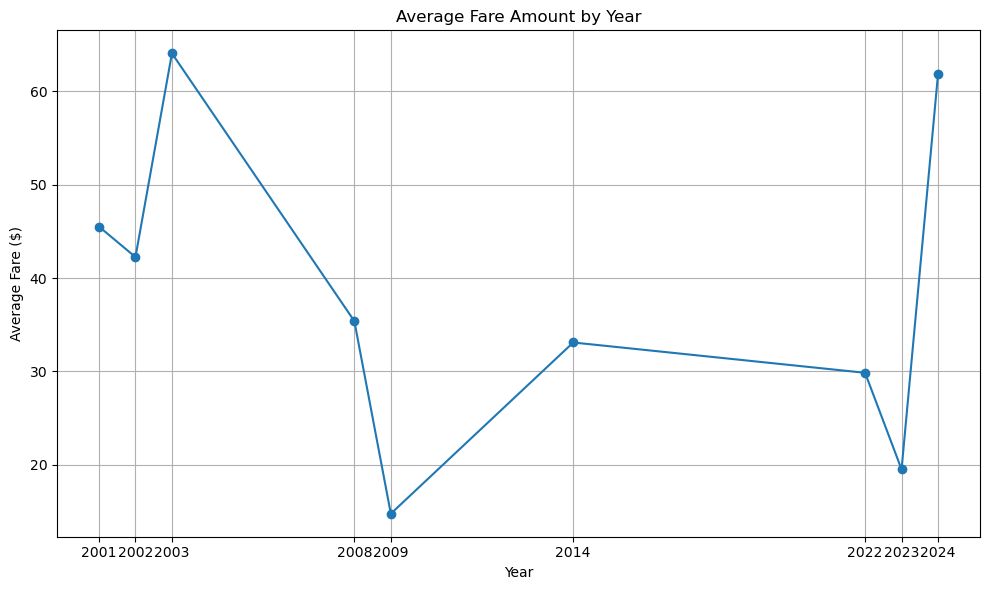

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(
    avg_fare_per_year["Year"],
    avg_fare_per_year["avg_fare_amount"],
    marker="o"
)

plt.xticks(avg_fare_per_year["Year"])

plt.xlabel("Year")
plt.ylabel("Average Fare ($)")
plt.title("Average Fare Amount by Year")

plt.grid(True)

plt.tight_layout()
plt.show()


# Average trip duration in minutes?

In [ ]:
avg_trip_duration = (
    (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"])
      .dt.total_seconds().mean() / 60
) 

In [ ]:
avg_trip_duration

16.71684913796471

# What are the busiest times of the day?

In [ ]:
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour

trips_by_hour = (
    df.groupby("pickup_hour")
      .size()
      .reset_index(name="trips")
      .sort_values("trips", ascending=False)
)

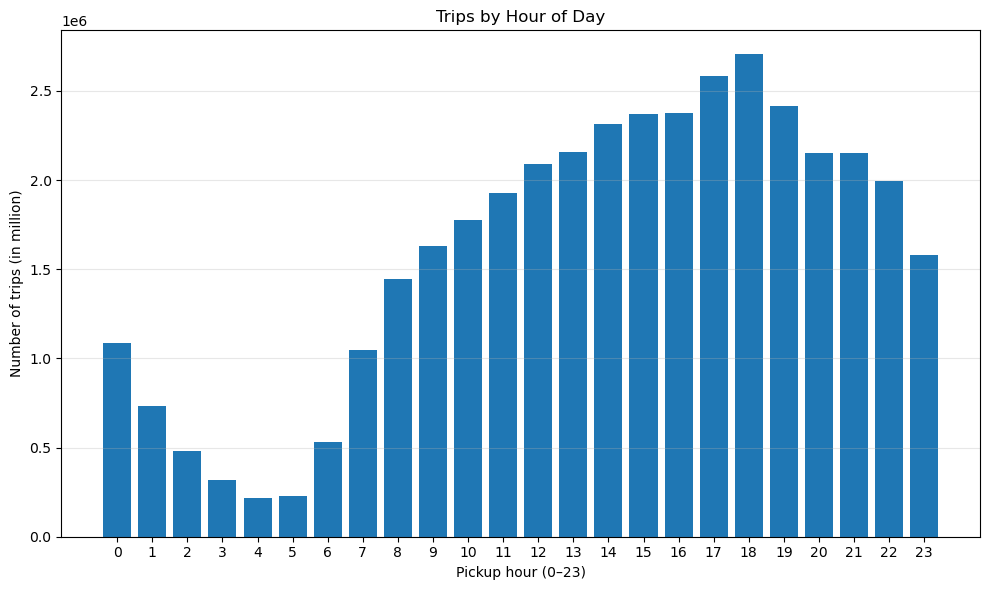

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(trips_by_hour["pickup_hour"], trips_by_hour["trips"])

plt.xlabel("Pickup hour (0–23)")
plt.ylabel("Number of trips (in million)")
plt.title("Trips by Hour of Day")
plt.xticks(range(0, 24))
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Busiest day of the week

In [ ]:
df["pickup_dow"] = df["tpep_pickup_datetime"].dt.day_name()

trips_by_dow = (
    df.groupby("pickup_dow")
      .size()
      .reset_index(name="trips")
)

dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
trips_by_dow["pickup_dow"] = pd.Categorical(trips_by_dow["pickup_dow"], categories=dow_order, ordered=True)
trips_by_dow = trips_by_dow.sort_values("pickup_dow")

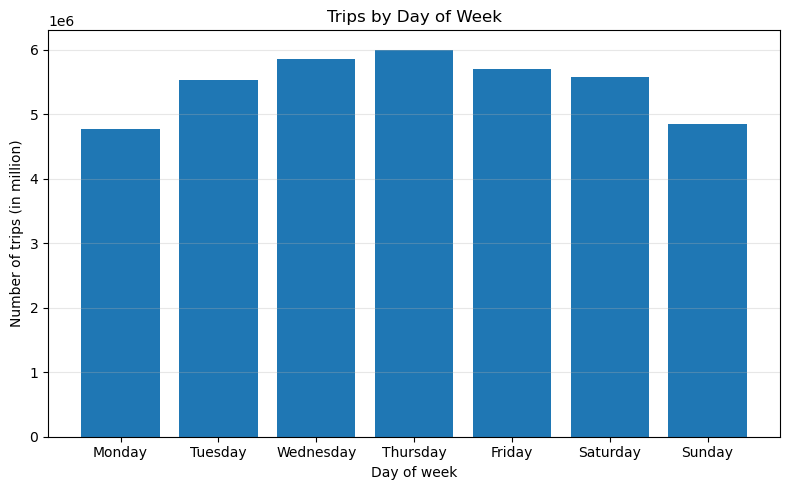

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(trips_by_dow["pickup_dow"], trips_by_dow["trips"])

plt.xlabel("Day of week")
plt.ylabel("Number of trips (in million)")
plt.title("Trips by Day of Week")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Do special holidays affect the fare & does the tip increase?

In [ ]:
df["pickup_date"] = df["tpep_pickup_datetime"].dt.normalize()


cal = USFederalHolidayCalendar()
holidays = cal.holidays(
    start=df["pickup_date"].min(),
    end=df["pickup_date"].max()
)

df["is_holiday"] = df["pickup_date"].isin(holidays)

holiday_vs_non = (
    df.groupby("is_holiday", as_index=False)
      .agg(
          trips=("is_holiday", "size"),
          avg_fare=("fare_amount", "mean"),
          avg_tip=("tip_amount", "mean"),
          tip_rate=("tip_amount", lambda s: (s > 0).mean()),
      )
)

In [ ]:
holiday_vs_non

,is_holiday,trips,avg_fare,avg_tip,tip_rate
0,False,37471023,19.474852,3.520331,0.763847
1,True,839203,20.693454,3.603676,0.735942


# At what time of the day do people tip more?

In [ ]:
tip_by_hour = (
    df.groupby("pickup_hour", as_index=False)
      .agg(
          trips=("pickup_hour", "size"),
          avg_tip=("tip_amount", "mean"),
          tip_rate=("tip_amount", lambda s: (s > 0).mean()),  
          avg_tip_pct=("tip_amount", lambda s: None),   
      )
)

tip_pct_by_hour = (
    df.groupby("pickup_hour")
      .apply(lambda g: g["tip_amount"].sum() / g["fare_amount"].sum())
)

tip_by_hour["avg_tip_pct"] = tip_by_hour["pickup_hour"].map(tip_pct_by_hour)

/var/folders/6_/4pssx0rj0ln4w7ysqm50xw400000gn/T/ipykernel_3484/2372484252.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g["tip_amount"].sum() / g["fare_amount"].sum())


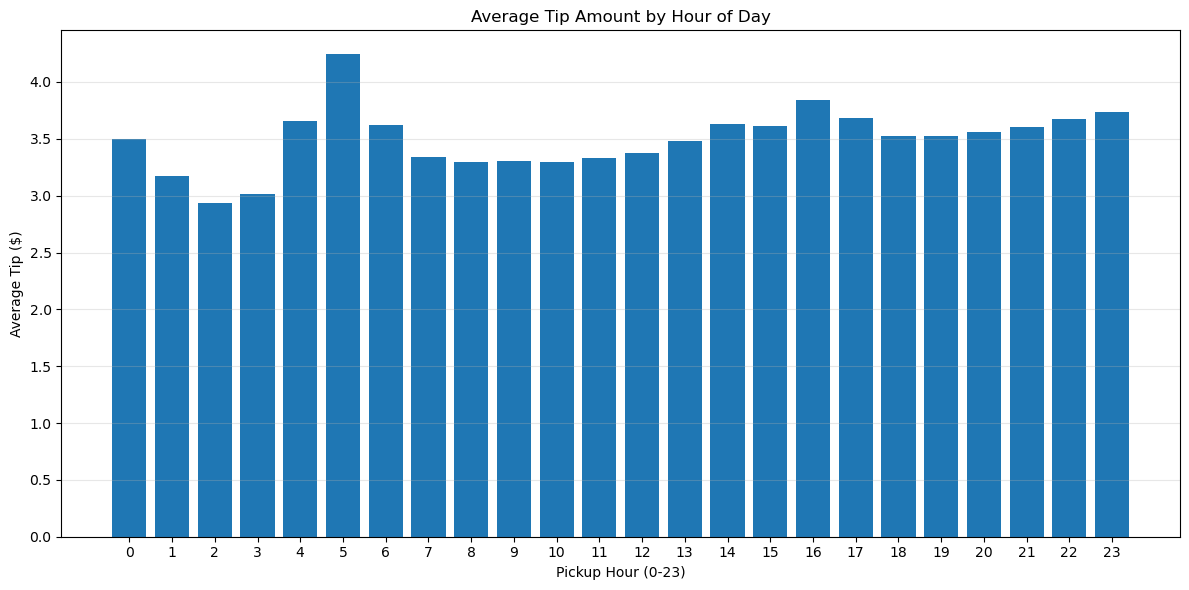

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(tip_by_hour["pickup_hour"], tip_by_hour["avg_tip"])

plt.xlabel("Pickup Hour (0-23)")
plt.ylabel("Average Tip ($)")
plt.title("Average Tip Amount by Hour of Day")
plt.xticks(range(0, 24))
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Correlation between passengers, trip, and tip?

In [ ]:
df2 = df[
    df["passenger_count"].between(1, 6) &
    (df["total_amount"] > 0) &
    (df["fare_amount"] > 0)
].copy()

df2["tip_pct"] = df2["tip_amount"] / df2["fare_amount"]

by_pax = (
    df2.groupby("passenger_count", as_index=False)
       .agg(
           trips=("passenger_count", "size"),
           avg_total=("total_amount", "mean"),
           median_total=("total_amount", "median"),
           avg_tip=("tip_amount", "mean"),
           tip_rate=("tip_amount", lambda s: (s > 0).mean()),
           avg_tip_pct=("tip_pct", "mean"),
       )
       .sort_values("passenger_count")
)

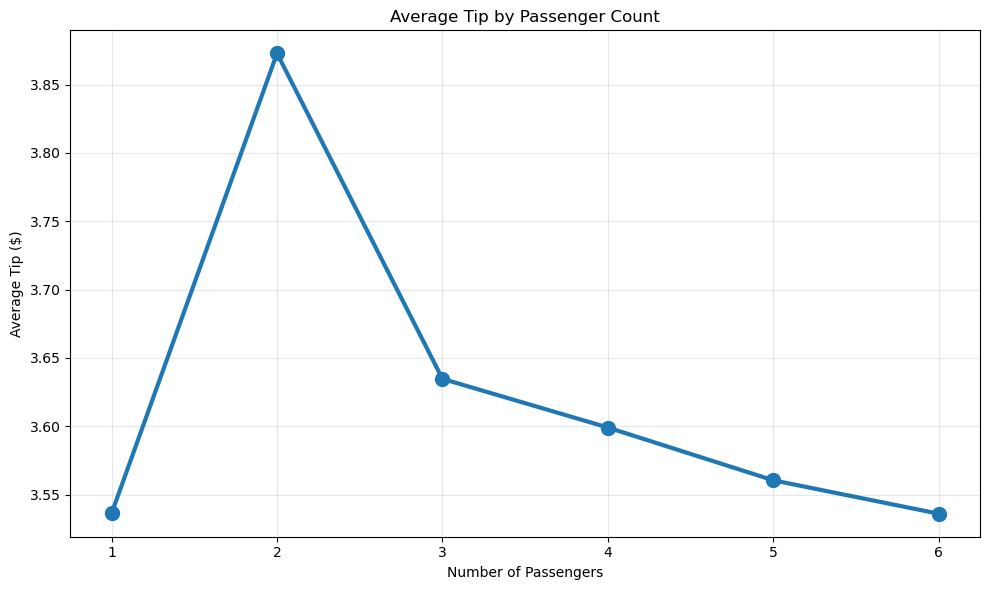

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(by_pax["passenger_count"], by_pax["avg_tip"], marker='o', linewidth=3, markersize=10)

plt.xlabel("Number of Passengers")
plt.ylabel("Average Tip ($)")
plt.title("Average Tip by Passenger Count")
plt.xticks(range(1, 7))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Airport Tip Comparison

In [ ]:
df["is_airport_pickup"] = df["airport_fee"].fillna(0).gt(0)

pickup_tip_compare = (
    df.groupby("is_airport_pickup", as_index=False)
      .agg(
          trips=("is_airport_pickup", "size"),
          avg_tip=("tip_amount", "mean"),
          tip_rate=("tip_amount", lambda s: (s > 0).mean()),
          tip_pct_of_fare=("tip_amount", lambda s: None),
      )
)

pickup_tip_compare["tip_pct_of_fare"] = (
    df.groupby("is_airport_pickup")
      .apply(lambda g: g["tip_amount"].sum() / g["fare_amount"].sum())
      .values
)

/var/folders/6_/4pssx0rj0ln4w7ysqm50xw400000gn/T/ipykernel_3484/437379433.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g["tip_amount"].sum() / g["fare_amount"].sum())


In [ ]:
plt.figure(figsize=(8, 6))
plt.bar(
    pickup_tip_compare["is_airport_pickup"],
    pickup_tip_compare["avg_tip"],
    color=['lightblue', 'orange']
)

plt.xlabel("Airport Pickup?")
plt.ylabel("Average Tip ($)")
plt.title("Do Airport Pickups Tip More?")
plt.xticks([0, 1], ["No (regular)", "Yes (airport)"])

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

,is_airport_pickup,trips,avg_tip,tip_rate,tip_pct_of_fare
0,False,35073087,3.034689,0.766741,0.186640
1,True,3237139,8.803672,0.725265,0.161161
